In [1]:
#load clean csv + import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf 
from datetime import datetime, timedelta
import time
import requests
from pandas_datareader import data as pdr
import numpy as np
import seaborn as sns

df = pd.read_csv('posts_clean.csv')
df.head(5)

,post_id,title,score,comments,author,created,source_endpoint,subreddit,feed
0,1tf2ppl,¿Qué pasa después del breakout del Opening Ran...,0,5,mariodoblep,2026-05-16 19:11:00,new,unknown,new
1,1text64,Do I freak the fuck out and sell it all?,66,126,ZaraBloom418,2026-05-16 16:06:00,new,unknown,new
2,1texmf0,Is the SOFI hype warranted?,38,57,ZTB1313,2026-05-16 16:00:00,new,unknown,new
3,1texhaz,"So uhh, when do I get the forbidden phone (mar...",31,35,DeltaVx_,2026-05-16 15:54:00,new,unknown,new
4,1tex6av,"China, US agree to reduce tariffs on unspecifi...",581,119,Force_Hammer,2026-05-16 15:43:00,new,unknown,new


In [2]:
# loading and checking columns, dates, and ticket format

top_5_df = pd.read_parquet("top_5_df.parquet")

#date shows as dtype object, change to datatime format 
df["created"] = pd.to_datetime(df["created"], errors="coerce")
print(top_5_df.columns)
print(top_5_df["created"].dtype)
print(top_5_df["created"].min(), top_5_df["created"].max()) 
print(top_5_df["ticker"].value_counts())

Index(['post_id', 'title', 'score', 'comments', 'author', 'created',
       'source_endpoint', 'subreddit', 'feed', 'ticker'],
      dtype='object')
datetime64[ns]
2025-05-22 01:34:00 2026-05-19 03:55:00
ticker
AMD     72
SPY     66
NVDA    61
MU      57
MSFT    55
Name: count, dtype: int64


# Quick Dataset Check
The filtered dataset looks clean and ready to use. It has the expected columns, the `created` field is properly formatted as a datetime, and the data spans from **May 22, 2025** to **May 19, 2026**.
The most common tickers are **AMD**, **SPY**, **NVDA**, **MU**, and **MSFT**, with AMD appearing the most at **72 posts**.

# Get Historical OHLCV for top tickers

In [3]:
#setting price based on data 

price_start = top_5_df["created"].min().date() - pd.Timedelta(days=7)
print(price_start)

price_end = top_5_df["created"].max().date() + pd.Timedelta(days=7)
print(price_end)


2025-05-15
2026-05-26


## OHLCV Data Source

I collected daily OHLCV price data from Stooq (https://stooq.com/) for the top five tickers in the Reddit dataset: AMD, MSFT, MU, NVDA, and SPY.

The data was downloaded manually from Stooq using the project date range, then saved as individual CSV files before being loaded and combined in Python.

In [6]:
#load the financial data and merge

tickers = top_5_df["ticker"].unique().tolist() # avoids hardcoding tickers

ohlcv_data = []

for ticker in tickers:
    file_name = f"{ticker.lower()}_us.csv"

    df = pd.read_csv(file_name)

    df["Date"] = pd.to_datetime(df["Date"], format="mixed") 

    df["ticker"] = ticker

    ohlcv_data.append(df)

ohlcv_df = pd.concat(ohlcv_data, ignore_index=True)

In [7]:
ohlcv_df 

,Date,Open,High,Low,Close,Volume,ticker
0,2025-05-15,117.020,117.5000,114.010,114.9900,43843235,AMD
1,2025-05-16,118.070,118.2400,116.010,117.1700,43419695,AMD
2,2025-05-19,115.015,115.5300,114.060,114.7400,37737373,AMD
3,2025-05-20,114.350,114.5100,112.080,113.5100,29030815,AMD
4,2025-05-21,113.850,116.1000,111.090,112.0600,43594606,AMD
...,...,...,...,...,...,...,...
1280,2026-05-18,229.870,230.0000,218.370,222.3200,146280896,NVDA
1281,2026-05-19,219.620,224.4800,217.910,220.6100,140948207,NVDA
1282,2026-05-20,223.180,226.1300,220.495,223.4700,184201587,NVDA
1283,2026-05-21,222.290,227.3999,217.930,219.5100,203381760,NVDA


In [8]:
ohlcv_df["Date"] = pd.to_datetime(ohlcv_df["Date"], errors="coerce")
ohlcv_df["Date"].dtype

dtype('<M8[ns]')

In [9]:
# Grouping & aggregating

ohlcv_df.groupby("ticker")["Date"].agg(["min", "max", "count"])

,min,max,count
ticker,,,
AMD,2025-05-15,2026-05-22,257
MSFT,2025-05-15,2026-05-22,257
MU,2025-05-15,2026-05-22,257
NVDA,2025-05-15,2026-05-22,257
SPY,2025-05-15,2026-05-22,257


In [10]:
ohlcv_df.to_parquet("top_5_ohlcv.parquet", index=False)

In [11]:
# creating an engagement metric based on score & comments (mitigates laarge engagement differences) 

top_5_df['engagement'] = np.log1p(top_5_df['score']) + np.log1p(top_5_df['comments'])  #log1p handles 0 

top_5_df['Date'] = pd.to_datetime(top_5_df['created'].dt.date) # this removes the time portion

daily_engagement = (top_5_df.groupby(['ticker', 'Date'])['engagement'].sum().reset_index()) #grouping by ticker and date

In [12]:
daily_engagement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ticker      193 non-null    object        
 1   Date        193 non-null    datetime64[ns]
 2   engagement  193 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 4.7+ KB


In [13]:
#merging on Date and Ticker
merged_df = ohlcv_df.merge(daily_engagement,
                           on=['ticker', 'Date'],
                           how='left')

In [14]:
# filling missing values

merged_df['engagement'] = merged_df['engagement'].fillna(0)
print(merged_df['engagement'].isna().sum())
print((merged_df["engagement"] != 0).sum()) # 146 days have Reddit engagement 



0
146


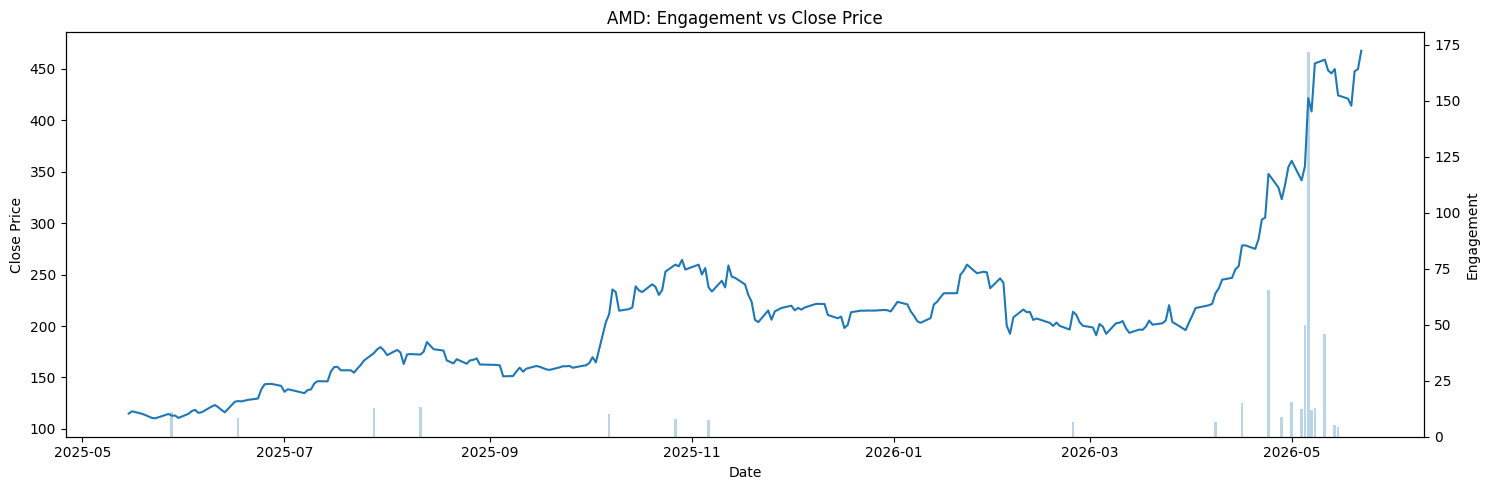

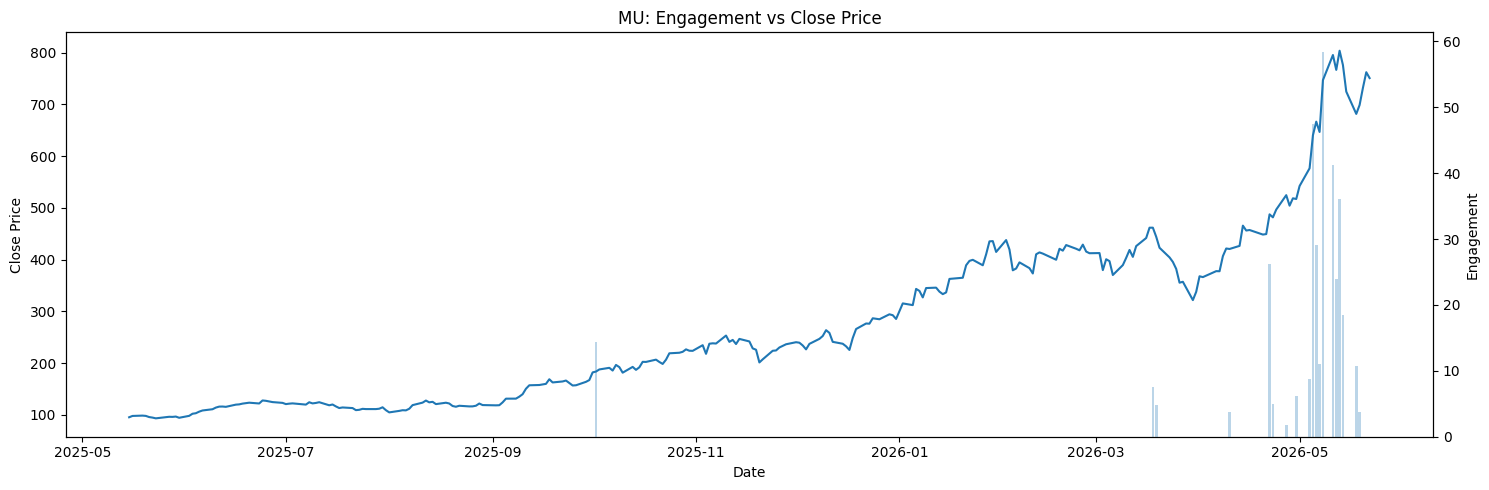

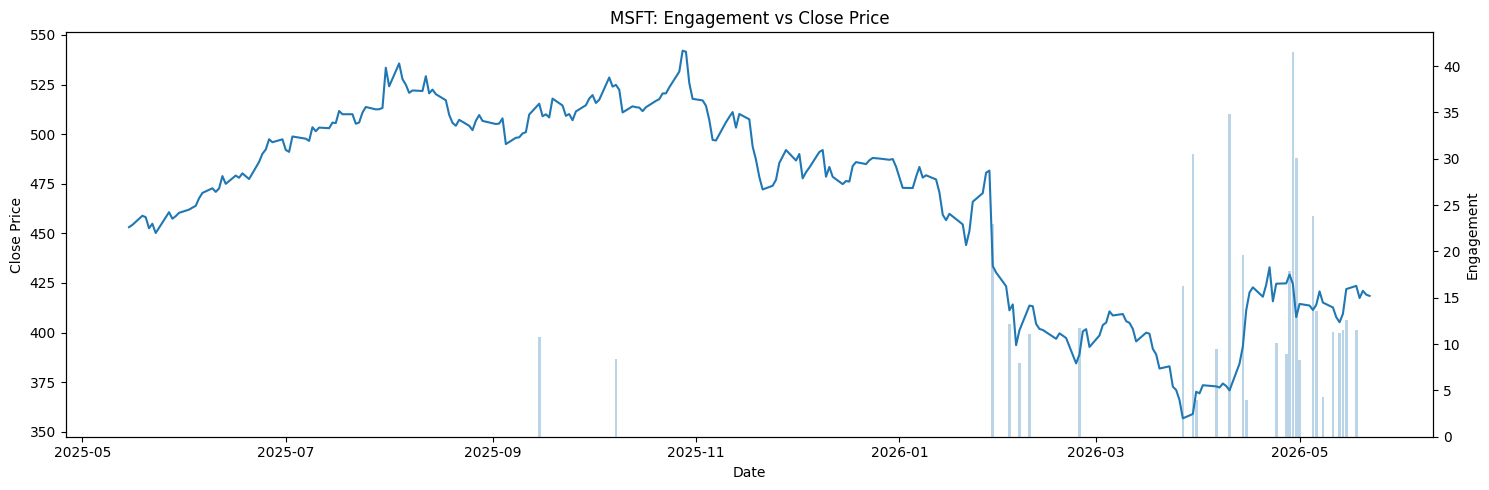

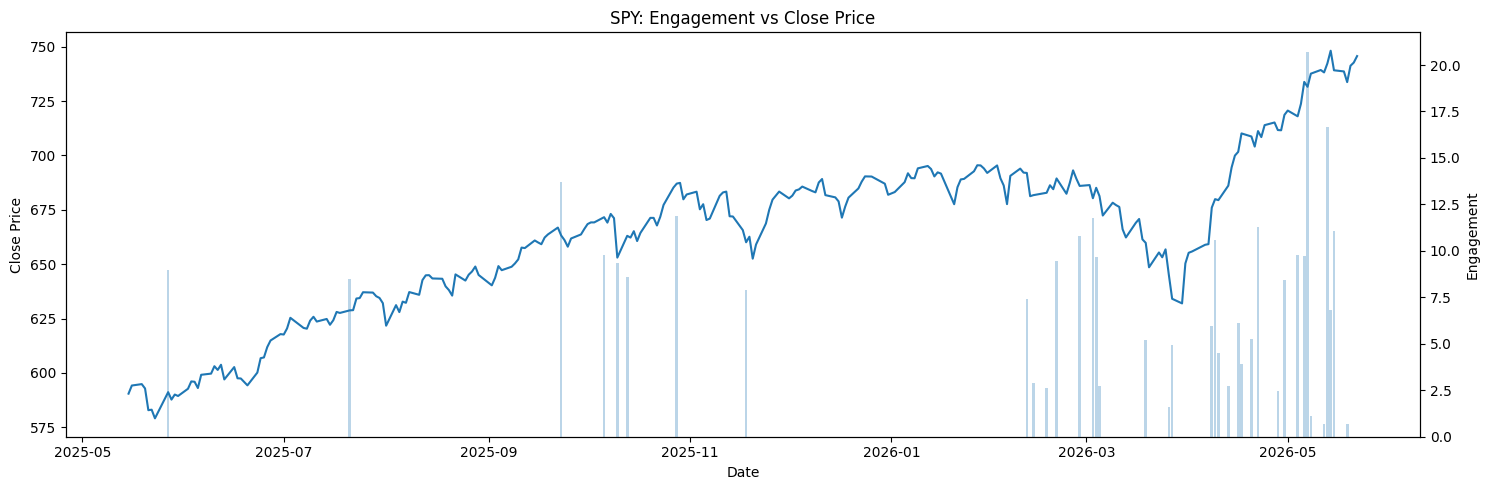

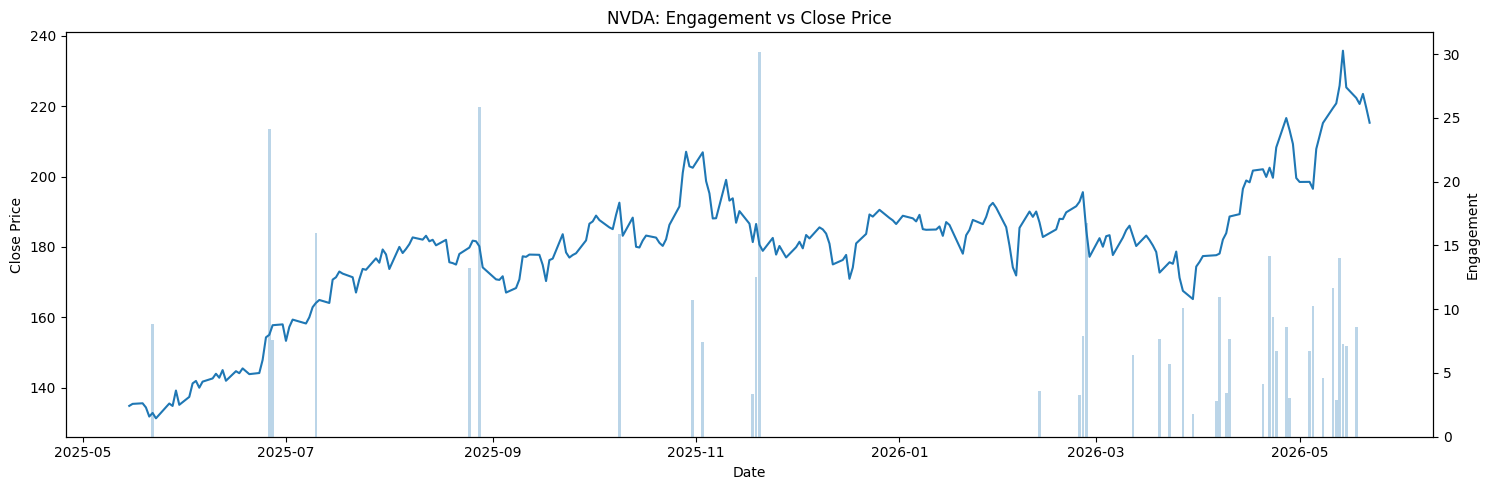

In [15]:
# Visualization of engagement vs. price

tickers = top_5_df["ticker"].unique().tolist()

for ticker in tickers:
    # one ticker at a time sorted by date
    
    stock = merged_df[merged_df['ticker'] == ticker].sort_values('Date')
    fig, price_axis = plt.subplots(figsize=(15,5))
    
    # plotting closing price
    
    price_axis.plot(stock['Date'], stock['Close'])
    price_axis.set_xlabel('Date')
    price_axis.set_ylabel('Close Price')
    
    # plotting engagement on second y-axis
    
    engagement_axis = price_axis.twinx()
    engagement_axis.bar(stock["Date"], stock["engagement"], alpha=0.3)
    engagement_axis.set_ylabel("Engagement")
    
    plt.title(f"{ticker}: Engagement vs Close Price")
    plt.tight_layout()
    plt.savefig(f"charts/engagement_vs_price_{ticker}.png", dpi=150, bbox_inches="tight")
    plt.show()

A visual inspection of the charts shows that Reddit engagement appears more often when prices are moving more actively, especially during noticeable increases or drops. However, since the charts compare same-day engagement with closing prices, we can’t tell yet whether Reddit activity happened before the market movement or after it. At this stage, this should be viewed as an early pattern worth exploring further, not as evidence that engagement predicts price changes.

In [16]:
# Calculate daily return

merged_df = merged_df.sort_values(['ticker', 'Date']) 

merged_df['daily_return'] = merged_df.groupby('ticker')['Close'].pct_change()

merged_df["abs_daily_return"] = merged_df["daily_return"].abs()
merged_df

,Date,Open,High,Low,Close,Volume,ticker,engagement,daily_return,abs_daily_return
0,2025-05-15,117.020,117.500,114.01,114.99,43843235,AMD,0.000000,NaN,NaN
1,2025-05-16,118.070,118.240,116.01,117.17,43419695,AMD,0.000000,0.018958,0.018958
2,2025-05-19,115.015,115.530,114.06,114.74,37737373,AMD,0.000000,-0.020739,0.020739
3,2025-05-20,114.350,114.510,112.08,113.51,29030815,AMD,0.000000,-0.010720,0.010720
4,2025-05-21,113.850,116.100,111.09,112.06,43594606,AMD,0.000000,-0.012774,0.012774
...,...,...,...,...,...,...,...,...,...,...
1023,2026-05-18,739.830,741.415,733.39,738.65,47843865,SPY,0.000000,-0.000703,0.000703
1024,2026-05-19,734.780,737.650,731.53,733.73,54255913,SPY,0.693147,-0.006661,0.006661
1025,2026-05-20,735.710,741.870,733.89,741.25,45768035,SPY,0.000000,0.010249,0.010249
1026,2026-05-21,738.640,744.870,737.03,742.72,43332225,SPY,0.000000,0.001983,0.001983


In [17]:
# lag loop to learn about Reddit engagement patterns

results = []

tickers = top_5_df["ticker"].unique().tolist()

for ticker in tickers:
    stock = merged_df[merged_df['ticker'] == ticker].sort_values('Date')
    for k in range(-7, 8): # adding a -7 to 7 lag
        shifted = stock['engagement'].shift(k) # .shift() allows us to shift values by a number of periods. In this case it is by k
        corr = shifted.corr(stock["abs_daily_return"])
        results.append({'ticker': ticker, 'lag': k, 'correlation': corr})

corr_df = pd.DataFrame(results)
corr_df.head(20)

,ticker,lag,correlation
0,AMD,-7,0.075404
1,AMD,-6,0.070825
2,AMD,-5,0.042656
3,AMD,-4,0.050652
4,AMD,-3,0.080884
5,AMD,-2,0.105478
6,AMD,-1,0.109928
7,AMD,0,0.387120
8,AMD,1,0.103081
9,AMD,2,0.169930


In [18]:
corr_summary = (corr_df.groupby("ticker").agg(
    
        max_positive_corr=("correlation", "max"),
        max_negative_corr=("correlation", "min"),
        avg_corr=("correlation", "mean"),
        avg_abs_corr=("correlation", lambda x: x.abs().mean()))
    .reset_index()
)

corr_summary

,ticker,max_positive_corr,max_negative_corr,avg_corr,avg_abs_corr
0,AMD,0.387120,-0.053789,0.085569,0.092741
1,MSFT,0.246427,0.007460,0.110728,0.110728
2,MU,0.330559,0.056851,0.157558,0.157558
3,NVDA,0.175821,-0.027298,0.044766,0.056576
4,SPY,0.155624,-0.061025,0.034603,0.056878


In [19]:
corr_df.loc[corr_df.groupby('ticker')['correlation'].idxmax()]

,ticker,lag,correlation
7,AMD,0,0.387120
37,MSFT,0,0.246427
22,MU,0,0.330559
68,NVDA,1,0.175821
52,SPY,0,0.155624


Reddit engagement mostly moved with price changes, not clearly before them. Four of the top five tickers had their strongest correlation on the same day as the return. AMD showed the strongest relationship, followed by MU and MSFT, while SPY was the weakest. Overall, the correlations were too weak to claim Reddit predicts returns, but they suggest Reddit activity is more reactive or same-day.

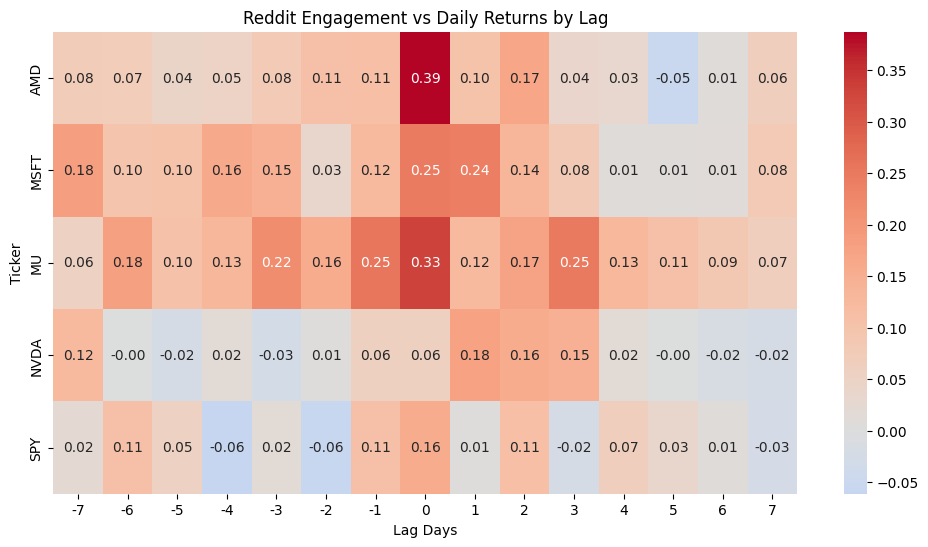

In [20]:
lag_heatmap = corr_df.pivot(index="ticker", columns="lag",values="correlation")

plt.figure(figsize=(12, 6))

sns.heatmap(lag_heatmap, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Reddit Engagement vs Daily Returns by Lag")
plt.xlabel("Lag Days")
plt.ylabel("Ticker")
plt.savefig(f"charts/lag_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()